In [1]:
from qiskit.circuit import Parameter, QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from scipy.optimize import minimize 
from qiskit.circuit.library import QFT
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate

import random
import matplotlib.pyplot as plt
import scipy.linalg as scl
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeKyiv
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend = AerSimulator()

# backend=FakeKyiv()
# sampler = Sampler(backend = backend)
pm = generate_preset_pass_manager(backend=backend,optimization_level=2)

In [2]:


nb_qubits = 3

N = 2**nb_qubits
m = np.zeros((N,N))
for j in range(N):
    if j == N-1:
        break
    else:
       m[j,j+1] = -1 

for j in range(N):
    if j == N-1:
        break
    else:
       m[j+1,j] = -1 
for j in range(N):
   m[j,j] = 2 
m[0] = np.array([1]+ [0]*(N-1))
m[1,0] = 0

b = np.array([0,0.25,0.25,0.25,0.25,0.5,0.5,0.5])
m

array([[ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  2., -1.,  0.,  0.,  0.,  0.,  0.],
       [ 0., -1.,  2., -1.,  0.,  0.,  0.,  0.],
       [ 0.,  0., -1.,  2., -1.,  0.,  0.,  0.],
       [ 0.,  0.,  0., -1.,  2., -1.,  0.,  0.],
       [ 0.,  0.,  0.,  0., -1.,  2., -1.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -1.,  2., -1.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -1.,  2.]])

In [3]:
d,u = np.linalg.eig(m)
k = np.max(d)/np.min(d)


In [4]:
np.linalg.det(m)



7.999999999999998

In [5]:
def U_b(nb_qubits):
    circ = QuantumCircuit(nb_qubits)
    circ.prepare_state(b)
    return circ
U = U_b(nb_qubits)
b = np.array(Statevector(U_b(nb_qubits)))
b

array([1.80411242e-16+6.93889390e-17j, 2.50000000e-01+5.13478149e-16j,
       2.50000000e-01-2.98372438e-16j, 2.50000000e-01-3.33066907e-16j,
       2.50000000e-01-6.66133815e-16j, 5.00000000e-01-6.10622664e-16j,
       5.00000000e-01+6.80011603e-16j, 5.00000000e-01+7.21644966e-16j])

In [6]:
def Hamiltonian(m):
    Ub = np.array(Operator(U_b(nb_qubits)))
    z = np.array([[1,0],
                 [0,-1]])
    I = np.array([[1,0],
                 [0,1]])
    def tensor(j,k,l):
        return np.kron(j,np.kron(k,l))
    M1 = (np.dot(np.dot(Ub,tensor(z,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,z,I)),np.conj(Ub.T))
          +np.dot(np.dot(Ub,tensor(I,I,z)),np.conj(Ub.T)))
    M = 0.5*np.dot(np.dot(np.conj(m.T),(tensor(I,I,I) - M1/nb_qubits)),m)

    return M
A = Hamiltonian(m)

In [7]:
d,u = np.linalg.eig(A)
d

array([ 1.07137160e+01+4.60313931e-30j,  5.17089365e+00+4.54046984e-31j,
        4.37778335e+00-1.58546536e-30j,  2.55258866e+00+3.93905099e-30j,
        7.69885428e-01+6.47252844e-32j,  4.68684258e-01+2.35468363e-30j,
        1.06162203e-01-7.20815494e-31j, -1.90838462e-16-1.22075630e-30j])

[0.52822308 0.40519007 0.48765494 0.56605484 0.25056377 0.60720049
 0.53942809 0.61184558 0.99554639 0.74489715 0.81785207 0.25282619
 0.41243963 0.11381233 0.76354501 0.12637757 0.54608607 0.65329402
 0.20654193 0.89865501 0.5440122  0.26823429 0.24008469 0.44891939
 0.56125941 0.05261654 0.02638421 0.06759133 0.32614957 0.39266204
 0.19674497 0.49752617 0.77267437 0.36766943 0.13459572 0.19071781
 0.32369167 0.16330848 0.97698898 0.77080536 0.9932332  0.01020086
 0.46480411 0.36827222 0.85136601 0.56377214 0.76375202 0.70418403
 0.51832791 0.95456412 0.07161198 0.87443302 0.80597287 0.3618098 ]


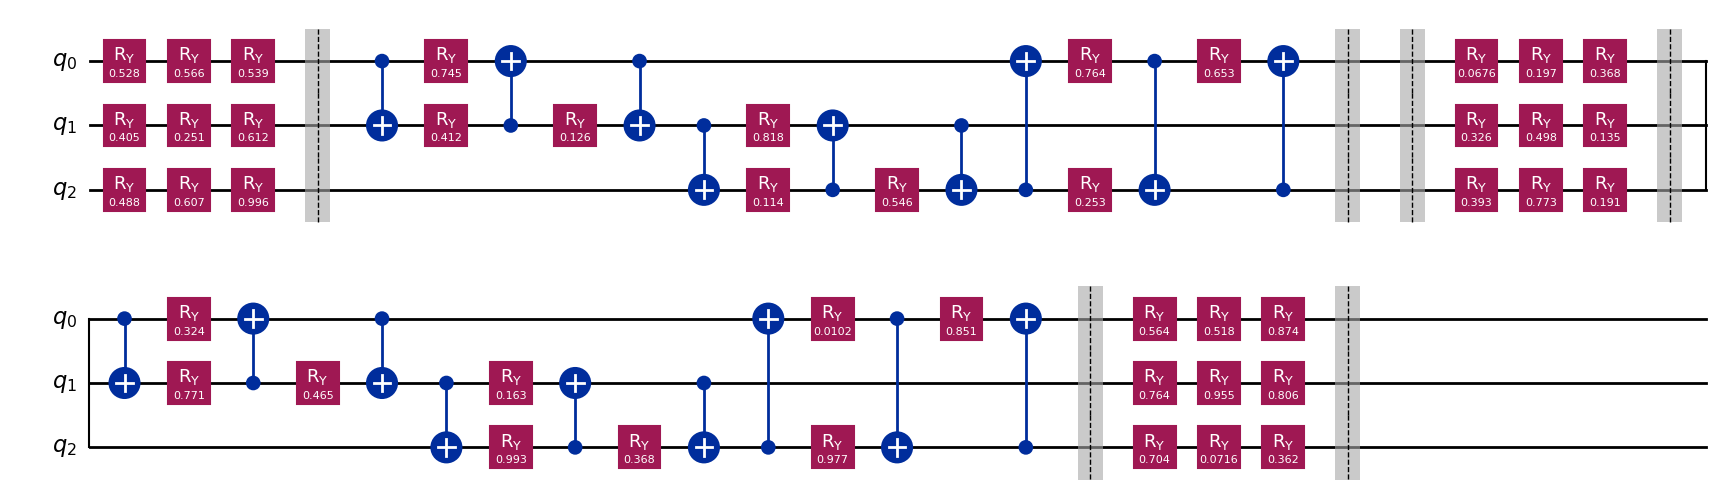

In [8]:

def ansatz(Parameters):
    qc = QuantumCircuit(N)
    for d in range(depth):
        param1=Parameters[d*9*N:(d+1)*(9*N)]
        for q in range(N):
            qc.ry(param1[q],qubits[q])
            qc.ry(param1[q+N],qubits[q])
            qc.ry(param1[q+2*N],qubits[q])
        qc.barrier()
        for q in range(N):
            qc.cx(qubits[q], qubits[(q+1)% N])
            qc.ry(param1[q+3*N],qubits[q])
            qc.ry(param1[q+4*N],qubits[(q+1)% N])
            qc.cx(qubits[(q+1)% N], qubits[q])
            qc.ry(param1[q+5*N],qubits[(q+1)% N])
            qc.cx(qubits[q], qubits[(q+1)% N])
        qc.barrier()
        if d==depth-1:
            for q in range(N):
                qc.ry(param1[q+6*N],qubits[q])
                qc.ry(param1[q+7*N],qubits[q])
                qc.ry(param1[q+8*N],qubits[q])
        qc.barrier()
    
    return qc

nb_qubits=3
depth=2
qubits=list(range(nb_qubits))
N=len(qubits)
nb_params=int(9*N*depth)

# Parameters = np.array([random.random() for _ in range(0, nb_params)])
Parameters = np.array([0.52822308, 0.40519007, 0.48765494, 0.56605484, 0.25056377,
       0.60720049, 0.53942809, 0.61184558, 0.99554639, 0.74489715,
       0.81785207, 0.25282619, 0.41243963, 0.11381233, 0.76354501,
       0.12637757, 0.54608607, 0.65329402, 0.20654193, 0.89865501,
       0.5440122 , 0.26823429, 0.24008469, 0.44891939, 0.56125941,
       0.05261654, 0.02638421, 0.06759133, 0.32614957, 0.39266204,
       0.19674497, 0.49752617, 0.77267437, 0.36766943, 0.13459572,
       0.19071781, 0.32369167, 0.16330848, 0.97698898, 0.77080536,
       0.9932332 , 0.01020086, 0.46480411, 0.36827222, 0.85136601,
       0.56377214, 0.76375202, 0.70418403, 0.51832791, 0.95456412,
       0.07161198, 0.87443302, 0.80597287, 0.3618098 ])
print(Parameters)
ansatz(Parameters).draw("mpl")


In [9]:

U1=scl.expm(2**0*2*np.pi*1j*A) 
U2=scl.expm(2**1*2*np.pi*1j*A) 
U3=scl.expm(2**2*2*np.pi*1j*A) 
U4=scl.expm(2**3*2*np.pi*1j*A) 
U5=scl.expm(2**4*2*np.pi*1j*A) 
U6=scl.expm(2**5*2*np.pi*1j*A) 
U7=scl.expm(2**6*2*np.pi*1j*A) 
U8=scl.expm(2**7*2*np.pi*1j*A)
 
u1gate = UnitaryGate(U1)
u2gate = UnitaryGate(U2)
u3gate=UnitaryGate(U3)
u4gate=UnitaryGate(U4)
u5gate=UnitaryGate(U5)
u6gate=UnitaryGate(U6)
u7gate=UnitaryGate(U7)
u8gate=UnitaryGate(U8)


C_u1gate=u1gate.control()
C_u2gate=u2gate.control()
C_u3gate=u3gate.control()
C_u4gate=u4gate.control()
C_u5gate=u5gate.control()
C_u6gate=u6gate.control()
C_u7gate=u7gate.control()
C_u8gate=u8gate.control()
    

In [11]:

def circ(parameters):
    x=QuantumRegister(11)
    c=ClassicalRegister(8)
    circuit = QuantumCircuit(x,c)
    phi=parameters
    circuit=circuit.compose(ansatz(parameters),x[8:11])
    circuit.h(x[0:8]) 
    circuit.append(C_u1gate, [x[0],x[8],x[9],x[10]])    
    circuit.append(C_u2gate, [x[1],x[8],x[9],x[10]])    
    circuit.append(C_u3gate, [x[2],x[8],x[9],x[10]])    
    circuit.append(C_u4gate, [x[3],x[8],x[9],x[10]]) 
    circuit.append(C_u5gate, [x[4],x[8],x[9],x[10]])
    circuit.append(C_u6gate, [x[5],x[8],x[9],x[10]])    
    circuit.append(C_u7gate, [x[6],x[8],x[9],x[10]]) 
    circuit.append(C_u8gate, [x[7],x[8],x[9],x[10]])
    circuit &= QFT(num_qubits = 8, approximation_degree = 0, do_swaps = True, 
                   inverse = True, insert_barriers = False, name='qft')
    circuit.measure(x[0:8],c)       
    return circuit

/tmp/ipykernel_2684135/8292215.py:16: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 8, approximation_degree = 0, do_swaps = True,


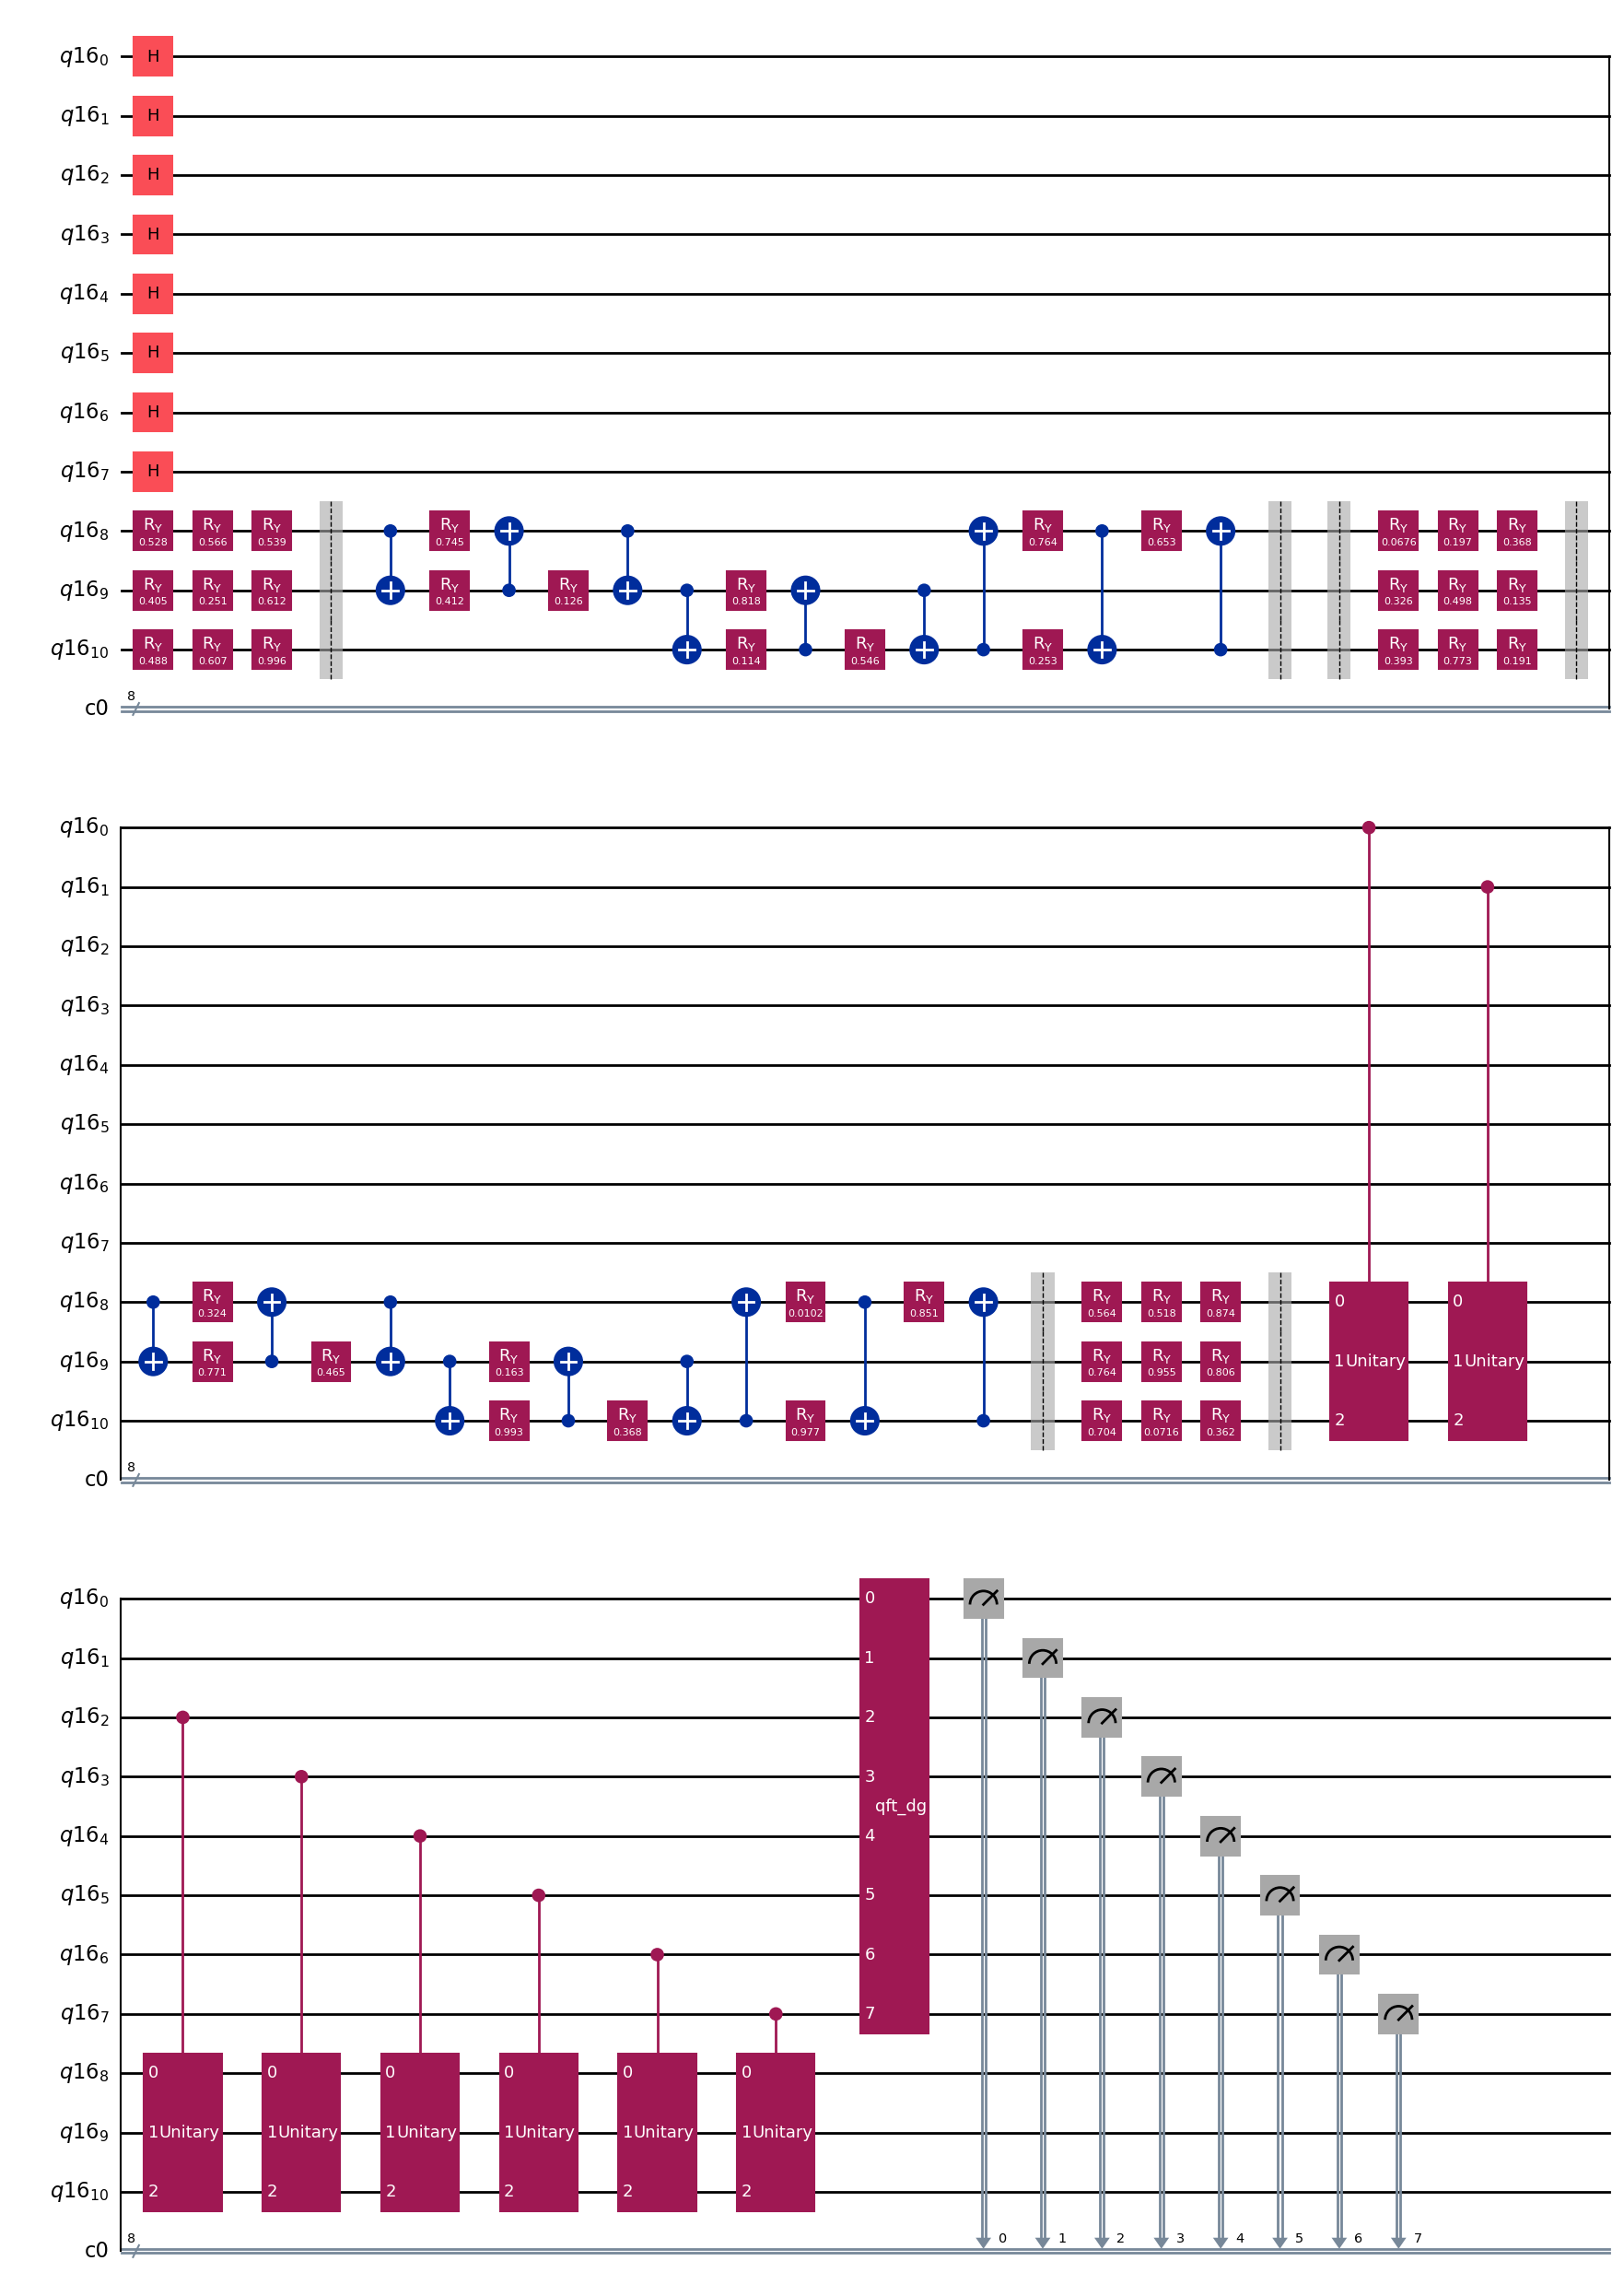

In [12]:
circ(Parameters).draw("mpl") 

In [13]:
shots = 100000
def cost(Parameters):
    job = backend.run(pm.run(circ(Parameters)),shots = shots).result()
    result = job.get_counts(0)
    if '00000000'not in result: 
        res = 1
    else:
        res = 1 - result['00000000']/shots
    return res
# cost(parameters)


In [14]:
from qiskit_algorithms.optimizers import GradientDescent

learning_rate = 0.1
def save(nfev,Parameters,cost,stepsize):
    global Cost,Params
    print(nfev,cost)
    Cost.append(cost)
    Params.append(Parameters)
Cost = []
Params = []

optimizer= GradientDescent(maxiter = 3000,learning_rate=learning_rate,tol=1e-4,callback=save)
optimizer.minimize(x0 = Parameters,fun = cost,jac=None)
    

/tmp/ipykernel_2684135/8292215.py:16: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits = 8, approximation_degree = 0, do_swaps = True,


55 0.98994
110 0.9847
165 0.97041
220 0.95361
275 0.93826
330 0.90968
385 0.87591
440 0.83307
495 0.7762100000000001
550 0.75618
605 0.71141
660 0.77473
715 0.6256200000000001
770 0.64598
825 0.45275
880 0.33658
935 0.23465999999999998
990 0.19296000000000002
1045 0.15666000000000002
1100 0.12544999999999995
1155 0.10872000000000004
1210 0.08165
1265 0.05349000000000004
1320 0.03885000000000005
1375 0.04761000000000004
1430 0.027179999999999982
1485 0.01817000000000002
1540 0.012290000000000023
1595 0.014410000000000034
1650 0.00817000000000001
1705 0.006349999999999967
1760 0.005190000000000028
1815 0.004850000000000021
1870 0.0043999999999999595
1925 0.002829999999999999
1980 0.0020799999999999708
2035 0.0020599999999999508
2090 0.0040200000000000236
2145 0.0016300000000000203
2200 0.0013600000000000279
2255 0.0011900000000000244
2310 0.0010200000000000209
2365 0.0020400000000000418
2420 0.0015100000000000113
2475 0.0006199999999999539
2530 0.00034000000000000696
2585 0.0002100000000

KeyboardInterrupt: 

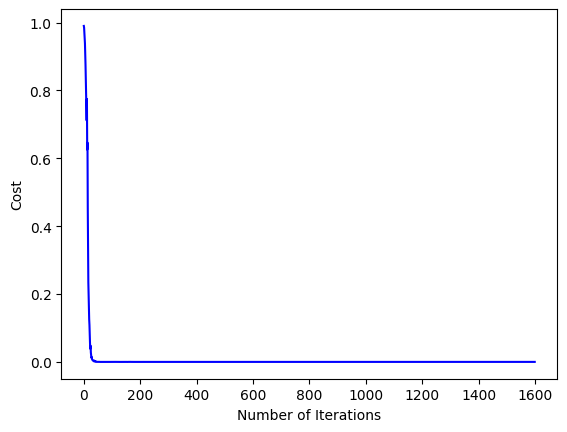

In [15]:
plt.plot(range(len(Cost)), Cost,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.show()


In [16]:
x_exact = np.linalg.solve(m,b)
x_exact = x_exact/np.linalg.norm(x_exact)

In [35]:
e = []
F =[ ]
norm_e = []
for k in range(len(Params)):
    state = np.array(Statevector(ansatz(Params[k])))
    psi = np.dot(m,state)
    Psi = psi/np.linalg.norm(psi)
    norm = np.dot(state,x_exact)
    e.append(state - x_exact/norm)
    # f = abs(np.dot(Psi,b))**2
    f = abs(np.dot(state,x_exact))**2
    F.append(f)

for v in e:
    norm_e.append(float(np.linalg.norm(v)))

Text(0.5, 0, 'Iteration')

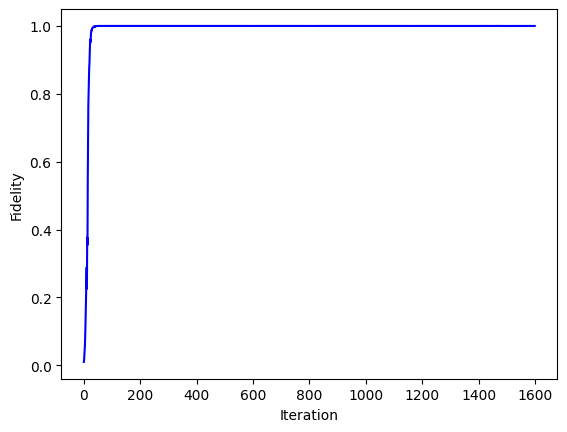

In [36]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(F)),F,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Fidelity')
plt.xlabel('Iteration')


In [37]:
norm_e[np.argmax(F)]

0.0033111190428307454

In [38]:
np.linalg.norm(np.real(e[np.argmax(F)]))

0.003311119042830746

Text(0.5, 0, 'Iteration')

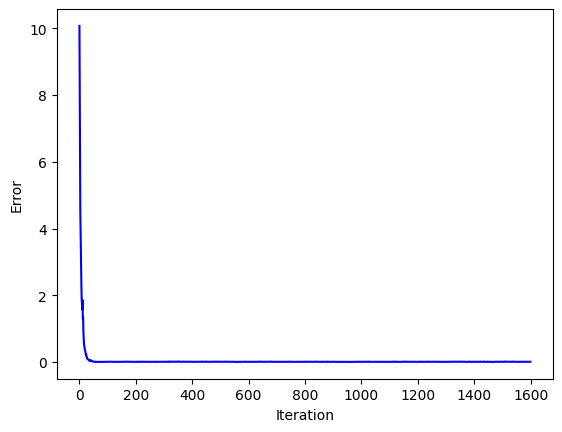

In [39]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(norm_e)),norm_e,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Error')
plt.xlabel('Iteration')

In [32]:
X_opt  = np.array(Statevector(ansatz(Params[np.argmax(F)])))
psi = m@X_opt
psi = psi/np.linalg.norm(psi)

In [33]:
abs(np.array(e[np.argmax(F)]))

array([1.10992793e-03, 2.06782800e-03, 8.38622918e-04, 1.57358720e-03,
       1.15049044e-03, 2.48344290e-05, 1.02453804e-03, 4.78759315e-04])

In [40]:
print(F)

[0.00975805746998139, 0.015071502094012475, 0.029034912461950085, 0.04621718366909097, 0.060376258402570895, 0.0896854381399612, 0.12355514536200062, 0.16619146089135264, 0.22252279400085054, 0.24498399319650363, 0.28854458595935506, 0.22528671937498965, 0.37658019291138545, 0.3545510794108516, 0.5479754620518384, 0.6643185734059706, 0.76662464202733, 0.8059363819752173, 0.8454078697141336, 0.8752298606700175, 0.8907211149472837, 0.9185509240032071, 0.9465397827637867, 0.960050677400484, 0.9520452996914254, 0.9721113416601275, 0.9820533078523375, 0.9873055749986154, 0.9863667934376432, 0.9917083848317153, 0.9938325127584166, 0.9945221337555133, 0.9953218571681102, 0.9956738456235537, 0.9970612226239066, 0.9982209585104338, 0.9980833525209589, 0.9960889583760291, 0.9983154256528531, 0.99855025166663, 0.9986328521462333, 0.9989868017121883, 0.9979372909923779, 0.9984770211442334, 0.9994010989906769, 0.9995419482011543, 0.9997225083290113, 0.9996908642616215, 0.9997467645424821, 0.9997040